# EDA — Romance

Exploración de datos para la categoría Romance. El foco está en entender metadatos, vacíos, distribución de ratings, taxonomías temáticas y el papel estructural de las series dentro del catálogo.

Este notebook es un **EDA diagnóstico**: busca entender forma, calidad, relaciones y rarezas del dato. No está organizado como notebook de CF ni de decisiones de modelado, y no documenta tareas de limpieza o procesamiento.

In [1]:
from pathlib import Path
import os
import sys
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import BOOK_NUMERIC_COLUMNS, CATEGORIES
from src.utils.io import read_jsonl_sample
from src.utils.cleaning import _shelves_summary
from src.utils.eda import (
    schema_summary,
    duplicate_summary,
    numeric_profile,
    iqr_outlier_summary,
    categorical_profile,
    author_profile,
    shelves_profile,
    series_profile,
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 140)

## 1. Carga e inspección inicial

Arrancamos con una muestra controlada de libros e interacciones. Antes de interpretar nada, conviene mirar forma, columnas y algunos ejemplos crudos para entender qué tipo de objetos trae Goodreads.

In [2]:
CATEGORY = 'romance'
cfg = CATEGORIES[CATEGORY]
BOOKS_SAMPLE = 20_000
INTERACTIONS_SAMPLE = 100_000

print(cfg.books_file)
print(cfg.interactions_file)
print(f'Muestra de libros: {BOOKS_SAMPLE:,}')
print(f'Muestra de interacciones: {INTERACTIONS_SAMPLE:,}')

/home/nakato/projects/BigBook/data/raw/goodreads_books_romance.json.gz
/home/nakato/projects/BigBook/data/raw/goodreads_interactions_romance.json.gz
Muestra de libros: 20,000
Muestra de interacciones: 100,000


In [3]:
books_raw = read_jsonl_sample(cfg.books_file, nrows=BOOKS_SAMPLE)
interactions_raw = read_jsonl_sample(cfg.interactions_file, nrows=INTERACTIONS_SAMPLE)

print(f'books_raw: {books_raw.shape}')
print(f'interactions_raw: {interactions_raw.shape}')

preview_books = pd.DataFrame({'column': books_raw.columns, 'dtype_aparente': books_raw.dtypes.astype(str)})
preview_inter = pd.DataFrame({'column': interactions_raw.columns, 'dtype_aparente': interactions_raw.dtypes.astype(str)})

print(); print('Columnas en books_raw'); display(preview_books)
print(); print('Columnas en interactions_raw'); display(preview_inter)
print(); print('Ejemplo de libros crudos'); display(books_raw.head(3))
print(); print('Ejemplo de interacciones crudas'); display(interactions_raw.head(3))

books_raw: (20000, 29)
interactions_raw: (100000, 10)

Columnas en books_raw


,column,dtype_aparente
isbn,isbn,str
text_reviews_count,text_reviews_count,str
series,series,object
country_code,country_code,str
language_code,language_code,str
popular_shelves,popular_shelves,object
asin,asin,str
is_ebook,is_ebook,str
average_rating,average_rating,str
kindle_asin,kindle_asin,str



Columnas en interactions_raw


,column,dtype_aparente
user_id,user_id,str
book_id,book_id,str
review_id,review_id,str
is_read,is_read,bool
rating,rating,int64
review_text_incomplete,review_text_incomplete,str
date_added,date_added,str
date_updated,date_updated,str
read_at,read_at,str
started_at,started_at,str



Ejemplo de libros crudos


,isbn,text_reviews_count,series,country_code,language_code,popular_shelves,asin,is_ebook,average_rating,kindle_asin,similar_books,description,format,link,authors,publisher,num_pages,publication_day,isbn13,publication_month,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series
0,,4,[],US,,"[{'count': '4', 'name': 'to-read'}, {'count': ...",,true,3.86,,[],Secrets. Sometimes keeping them in confidence ...,ebook,https://www.goodreads.com/book/show/34883016-p...,"[{'author_id': '5807700', 'role': ''}]",Gone Writing Publishing,,3,9781370889471,5,,2017,https://www.goodreads.com/book/show/34883016-p...,https://images.gr-assets.com/books/1493525974m...,34883016,5,56135087,Playmaker: A Venom Series Novella,Playmaker: A Venom Series Novella
1,,21,[811663],US,en-US,"[{'count': '598', 'name': 'to-read'}, {'count'...",B01BLJGA9S,true,4.23,B01BLJGA9S,"[25515353, 20483269, 25650829, 18913492, 22578...",,,https://www.goodreads.com/book/show/29074693-p...,"[{'author_id': '5360266', 'role': ''}]",,,,,,,,https://www.goodreads.com/book/show/29074693-p...,https://s.gr-assets.com/assets/nophoto/book/11...,29074693,149,46079519,"Prowled Darkness (Dante's Circle, #7)","Prowled Darkness (Dante's Circle, #7)"
2,1597371289,8,[],US,eng,"[{'count': '16215', 'name': 'classics'}, {'cou...",,false,3.99,B0083Z3O8Y,"[31242, 374380, 20564, 383206, 7891, 6335178, ...",The funny and heartwarming story of a young la...,Audio CD,https://www.goodreads.com/book/show/3209316-emma,"[{'author_id': '1265', 'role': ''}]",Brilliance Audio,544,25,9781597371285,9,,2005,https://www.goodreads.com/book/show/3209316-emma,https://s.gr-assets.com/assets/nophoto/book/11...,3209316,42,3360164,Emma,Emma



Ejemplo de interacciones crudas


,user_id,book_id,review_id,is_read,rating,review_text_incomplete,date_added,date_updated,read_at,started_at
0,8842281e1d1347389f2ab93d60773d4d,5526,c2b5f16df9f9c716617c07326b4f2869,False,0,,Wed Mar 29 00:27:40 -0700 2017,Wed Mar 29 00:27:40 -0700 2017,,
1,8842281e1d1347389f2ab93d60773d4d,18633693,611eea84ef983e27884953b8e45b55aa,False,0,,Tue Mar 28 21:01:27 -0700 2017,Tue Mar 28 21:01:27 -0700 2017,,
2,8842281e1d1347389f2ab93d60773d4d,22055137,9f149f1a24f51b01aed5b7e465134027,False,0,,Tue Mar 28 00:02:48 -0700 2017,Tue Mar 28 00:02:49 -0700 2017,,


## 2. Perfil general del dataset

A partir de acá armamos tablas analíticas de apoyo para describir el dato: esquema, nulos, cardinalidad, outliers y relaciones. El foco sigue siendo descriptivo.

In [4]:
def missing_with_empty_strings(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'nulls_raw': df.isna().sum(),
        'empty_strings_raw': df.astype('string').eq('').sum(),
        'non_null_raw': df.notna().sum(),
    })
    out['missing_like_total'] = out['nulls_raw'] + out['empty_strings_raw']
    out['missing_like_pct'] = out['missing_like_total'] / len(df) if len(df) else 0
    return out.sort_values(['missing_like_pct', 'empty_strings_raw'], ascending=False).reset_index(names='column')

books_num = books_raw.copy()
for col in BOOK_NUMERIC_COLUMNS:
    if col in books_num.columns:
        books_num[col] = pd.to_numeric(books_num[col], errors='coerce')

if 'popular_shelves' in books_num.columns:
    shelves_aux = books_num['popular_shelves'].map(lambda s: _shelves_summary(s, top_n=20)).apply(pd.Series)
    for col in ['shelf_count', 'to_read_count']:
        books_num[col] = shelves_aux[col]
if 'series' in books_num.columns:
    books_num['series_count'] = books_num['series'].map(lambda x: len(x) if isinstance(x, list) else 0)

interactions_num = interactions_raw.copy()
if 'rating' in interactions_num.columns:
    interactions_num['rating'] = pd.to_numeric(interactions_num['rating'], errors='coerce')
    interactions_num['rating_clean'] = interactions_num['rating'].where(interactions_num['rating'].between(1, 5), pd.NA)
    interactions_num['is_explicit'] = interactions_num['rating'].between(1, 5)
else:
    interactions_num['rating_clean'] = pd.NA
    interactions_num['is_explicit'] = False

for col in ['date_added', 'date_updated', 'read_at', 'started_at']:
    if col in interactions_num.columns:
        interactions_num[col] = pd.to_datetime(interactions_num[col], errors='coerce', utc=True)

interaction_agg = interactions_num.groupby('book_id', dropna=False).agg(
    interaction_count=('book_id', 'size'),
    explicit_rating_count=('rating_clean', lambda s: s.notna().sum()),
    mean_user_rating=('rating_clean', 'mean'),
).reset_index() if 'book_id' in interactions_num.columns else pd.DataFrame(columns=['book_id', 'interaction_count', 'explicit_rating_count', 'mean_user_rating'])

books_metrics = books_num.merge(interaction_agg, on='book_id', how='left') if 'book_id' in books_num.columns else books_num.copy()

summary = pd.DataFrame([
    {'metric': 'books_raw_rows', 'value': len(books_raw)},
    {'metric': 'interactions_raw_rows', 'value': len(interactions_raw)},
    {'metric': 'books_columns', 'value': books_raw.shape[1]},
    {'metric': 'interactions_columns', 'value': interactions_raw.shape[1]},
    {'metric': 'unique_book_id_books', 'value': books_raw['book_id'].nunique() if 'book_id' in books_raw.columns else np.nan},
    {'metric': 'unique_work_id_books', 'value': books_raw['work_id'].nunique() if 'work_id' in books_raw.columns else np.nan},
    {'metric': 'unique_user_id_interactions', 'value': interactions_raw['user_id'].nunique() if 'user_id' in interactions_raw.columns else np.nan},
    {'metric': 'explicit_rating_pct', 'value': interactions_num['is_explicit'].mean() if len(interactions_num) else np.nan},
])

books_schema = schema_summary(books_raw)
interactions_schema = schema_summary(interactions_raw)
books_missing_explicit = missing_with_empty_strings(books_raw)
interactions_missing_explicit = missing_with_empty_strings(interactions_raw)
duplicates = duplicate_summary(books_raw, interactions_raw)
books_numeric = numeric_profile(books_num, BOOK_NUMERIC_COLUMNS + ['shelf_count', 'to_read_count', 'series_count'])
interactions_numeric = numeric_profile(interactions_num, ['rating'])
books_outliers = iqr_outlier_summary(books_num, [c for c in BOOK_NUMERIC_COLUMNS + ['to_read_count', 'shelf_count', 'series_count'] if c in books_num.columns])
categoricals = categorical_profile(books_raw, ['language_code', 'format', 'publisher', 'country_code', 'is_ebook'])
author_artifacts = author_profile(books_raw)
shelf_artifacts = shelves_profile(books_raw, top_n=20)
series_artifacts = series_profile(books_raw)

In [5]:
print('Resumen general del muestreo')
display(summary)

Resumen general del muestreo


,metric,value
0,books_raw_rows,20000.00000
1,interactions_raw_rows,100000.00000
2,books_columns,29.00000
3,interactions_columns,10.00000
4,unique_book_id_books,20000.00000
5,unique_work_id_books,18524.00000
6,unique_user_id_interactions,1018.00000
7,explicit_rating_pct,0.48748


## 3. Esquema, nulos y vacíos

En Goodreads muchos faltantes aparecen como strings vacíos. Por eso miramos nulls y vacíos juntos antes de atribuir significado a la ausencia de un valor.

In [6]:
print('=== Esquema de books_raw ===')
display(books_schema)
print(); print('=== Esquema de interactions_raw ===')
display(interactions_schema)
print(); print('=== Books: nulls y vacíos efectivos ===')
display(books_missing_explicit.head(20))
print(); print('=== Interactions: nulls y vacíos efectivos ===')
display(interactions_missing_explicit.head(20))

=== Esquema de books_raw ===


,column,dtype,non_null,nulls,unique
0,asin,str,20000,0,7410
1,authors,object,20000,0,11111
2,average_rating,str,20000,0,276
3,book_id,str,20000,0,20000
4,country_code,str,20000,0,1
5,description,str,20000,0,17926
6,edition_information,str,20000,0,930
7,format,str,20000,0,63
8,image_url,str,20000,0,12339
9,is_ebook,str,20000,0,2



=== Esquema de interactions_raw ===


,column,dtype,non_null,nulls,unique
0,book_id,str,100000,0,41740
1,date_added,str,100000,0,98925
2,date_updated,str,100000,0,98723
3,is_read,bool,100000,0,2
4,rating,int64,100000,0,6
5,read_at,str,100000,0,17408
6,review_id,str,100000,0,100000
7,review_text_incomplete,str,100000,0,10156
8,started_at,str,100000,0,11534
9,user_id,str,100000,0,1018



=== Books: nulls y vacíos efectivos ===


,column,dtype,nulls_raw,empty_strings_raw,non_null_raw,missing_like_total,missing_like_pct
0,edition_information,str,0,17925,20000,17925,0.89625
1,asin,str,0,12591,20000,12591,0.62955
2,isbn,str,0,12189,20000,12189,0.60945
3,isbn13,str,0,9920,20000,9920,0.496
4,kindle_asin,str,0,9184,20000,9184,0.4592
5,num_pages,str,0,8168,20000,8168,0.4084
6,publication_day,str,0,7916,20000,7916,0.3958
7,publisher,str,0,7387,20000,7387,0.36935
8,publication_month,str,0,6880,20000,6880,0.344
9,format,str,0,6809,20000,6809,0.34045



=== Interactions: nulls y vacíos efectivos ===


,column,dtype,nulls_raw,empty_strings_raw,non_null_raw,missing_like_total,missing_like_pct
0,review_text_incomplete,str,0,89611,100000,89611,0.89611
1,started_at,str,0,81416,100000,81416,0.81416
2,read_at,str,0,73537,100000,73537,0.73537
3,user_id,str,0,0,100000,0,0.0
4,book_id,str,0,0,100000,0,0.0
5,review_id,str,0,0,100000,0,0.0
6,is_read,bool,0,0,100000,0,0.0
7,rating,int64,0,0,100000,0,0.0
8,date_added,str,0,0,100000,0,0.0
9,date_updated,str,0,0,100000,0,0.0


In [7]:
if 'rating' in interactions_raw.columns:
    rating_dist = interactions_raw['rating'].value_counts(dropna=False).sort_index().rename_axis('rating').reset_index(name='count')
    rating_dist['pct'] = rating_dist['count'] / len(interactions_raw)
    print('Distribución observada de rating')
    display(rating_dist)

print(); print('Ejemplos de campos anidados en books_raw')
display(books_raw[['authors', 'popular_shelves', 'series']].head(2))

Distribución observada de rating


,rating,count,pct
0,0,51252,0.51252
1,1,834,0.00834
2,2,2513,0.02513
3,3,10683,0.10683
4,4,19366,0.19366
5,5,15352,0.15352



Ejemplos de campos anidados en books_raw


,authors,popular_shelves,series
0,"[{'author_id': '5807700', 'role': ''}]","[{'count': '4', 'name': 'to-read'}, {'count': ...",[]
1,"[{'author_id': '5360266', 'role': ''}]","[{'count': '598', 'name': 'to-read'}, {'count'...",[811663]


## 4. Duplicados y llaves

En libros, `book_id` y `work_id` no cuentan lo mismo: uno identifica edición/registro y el otro obra. En interacciones, interesa saber si un review o un par usuario-libro aparece más de una vez.

In [8]:
display(duplicates)

if 'work_id' in books_raw.columns:
    repeated_works = (
        books_raw.groupby('work_id', dropna=False)
        .size()
        .rename('edition_count')
        .reset_index()
        .sort_values('edition_count', ascending=False)
    )
    print(); print('Obras con más ediciones/entradas en la muestra')
    display(repeated_works.head(15))

,key,duplicates,records
0,books.book_id,0,20000
1,books.work_id,1476,20000
2,interactions.review_id,0,100000
3,interactions.user_id_book_id,0,100000



Obras con más ediciones/entradas en la muestra


,work_id,edition_count
8268,3060926,25
1727,1565818,21
8550,3360164,13
9163,4039699,12
8539,3349450,11
8437,3237433,9
6413,2534720,9
8382,3185154,8
8596,3423015,7
1972,1622450,7


## 5. Variables numéricas y outliers

Acá el punto no es quitar atípicos por defecto, sino entender de qué tipo son. En Goodreads un valor extremo puede significar error, reedición rara o, muy seguido, cola larga natural de popularidad.

Perfil numérico de libros


,column,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
0,text_reviews_count,20000.0,40.210250,273.887613,0.0,1.0,1.00,3.00,9.00,26.00,130.00,483.01,20077.0
1,average_rating,20000.0,3.881062,0.377067,0.0,2.8,3.23,3.67,3.91,4.14,4.43,4.62,5.0
2,num_pages,11832.0,268.245352,153.360804,0.0,7.0,40.00,184.00,267.00,352.00,479.00,644.00,3200.0
3,publication_day,12084.0,13.303211,9.853395,1.0,1.0,1.00,4.00,13.00,22.00,29.00,31.00,31.0
4,publication_month,13120.0,6.564329,3.406160,1.0,1.0,1.00,4.00,7.00,10.00,12.00,12.00,12.0
5,publication_year,13873.0,2010.611620,29.218423,12.0,1982.0,1999.00,2010.00,2013.00,2015.00,2017.00,2017.00,2107.0
6,ratings_count,20000.0,493.313500,6830.539591,0.0,1.0,2.00,16.00,53.00,180.00,1349.00,6233.09,748926.0
7,shelf_count,20000.0,78.548600,30.206956,3.0,9.0,18.00,54.00,100.00,100.00,100.00,100.00,100.0
8,to_read_count,19867.0,2677.406352,28695.106496,1.0,4.0,12.00,56.00,205.00,750.00,4601.00,25374.70,742446.0
9,series_count,20000.0,0.664100,0.572440,0.0,0.0,0.00,0.00,1.00,1.00,1.00,2.00,4.0



Perfil numérico de interacciones


,column,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
0,rating,100000.0,1.92133,2.07736,0.0,0.0,0.0,0.0,0.0,4.0,5.0,5.0,5.0



Resumen IQR de outliers en libros


,column,q1,q3,iqr,p95,p99,upper_iqr_bound,outliers_iqr
0,text_reviews_count,3.00,26.00,23.00,130.00,483.01,60.500,2348
1,average_rating,3.67,4.14,0.47,4.43,4.62,4.845,31
2,num_pages,184.00,352.00,168.00,479.00,644.00,604.000,166
3,publication_day,4.00,22.00,18.00,29.00,31.00,49.000,0
4,publication_month,4.00,10.00,6.00,12.00,12.00,19.000,0
5,publication_year,2010.00,2015.00,5.00,2017.00,2017.00,2022.500,1
6,ratings_count,16.00,180.00,164.00,1349.00,6233.09,426.000,2770
7,to_read_count,56.00,750.00,694.00,4601.00,25374.70,1791.000,2516
8,shelf_count,54.00,100.00,46.00,100.00,100.00,169.000,0
9,series_count,0.00,1.00,1.00,1.00,2.00,2.500,101


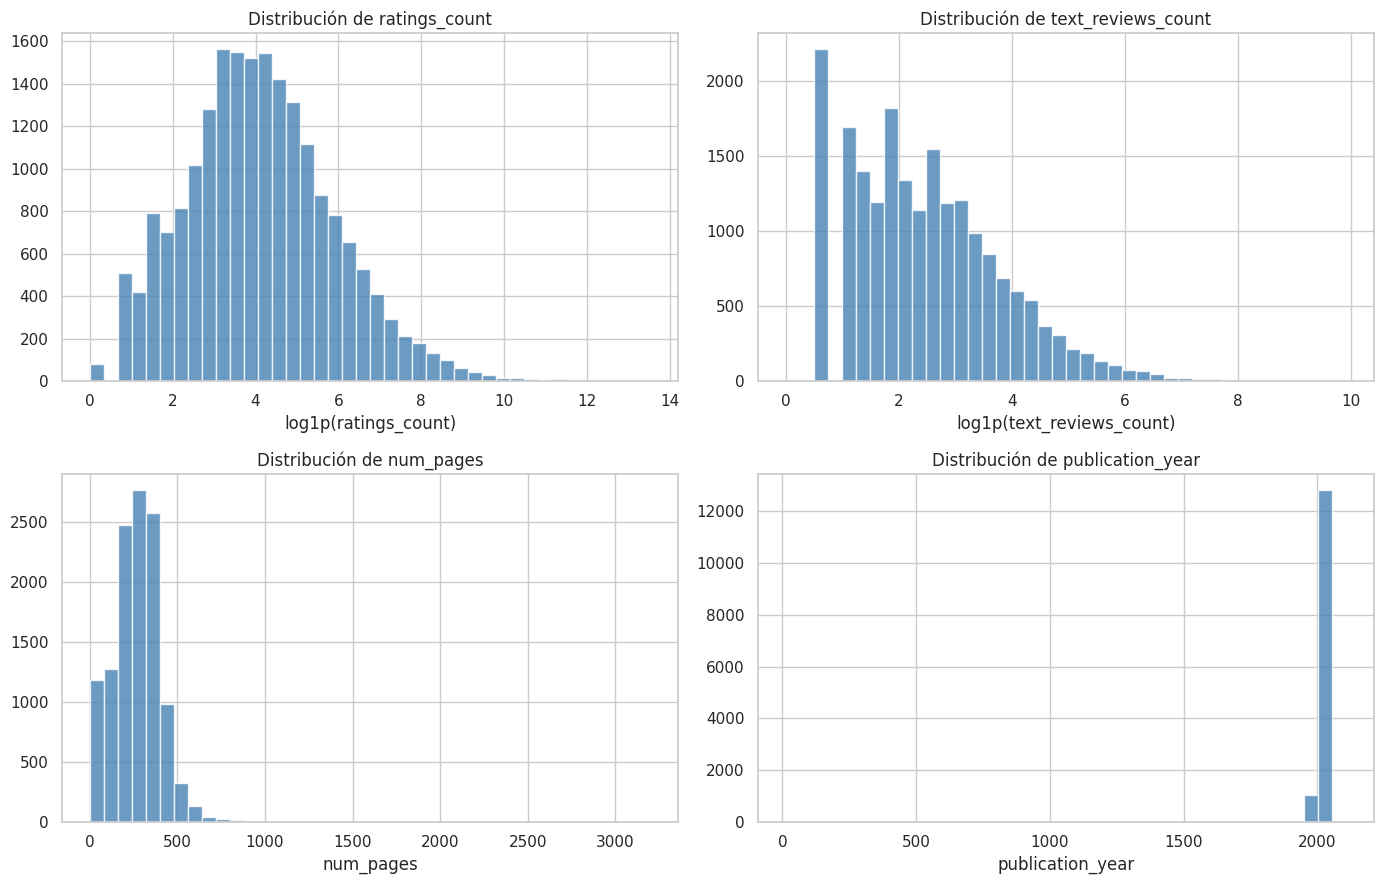

In [9]:
print('Perfil numérico de libros')
display(books_numeric)
print(); print('Perfil numérico de interacciones')
display(interactions_numeric)
print(); print('Resumen IQR de outliers en libros')
display(books_outliers)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plots = [
    ('ratings_count', 'Distribución de ratings_count', True),
    ('text_reviews_count', 'Distribución de text_reviews_count', True),
    ('num_pages', 'Distribución de num_pages', False),
    ('publication_year', 'Distribución de publication_year', False),
]
for ax, (col, title, use_log) in zip(axes.ravel(), plots):
    if col in books_num.columns:
        vals = pd.to_numeric(books_num[col], errors='coerce').dropna()
        if use_log:
            vals = np.log1p(vals)
            ax.set_xlabel(f'log1p({col})')
        else:
            ax.set_xlabel(col)
        ax.hist(vals, bins=40, color='steelblue', alpha=0.8)
        ax.set_title(title)
plt.tight_layout()
plt.show()

In [10]:
cols_contexto = [c for c in ['book_id', 'work_id', 'title', 'publication_year', 'ratings_count', 'text_reviews_count', 'num_pages', 'average_rating'] if c in books_num.columns]
print('Libros más populares en la muestra')
display(books_num[cols_contexto].sort_values('ratings_count', ascending=False).head(15))
print(); print('Libros más largos en la muestra')
display(books_num[cols_contexto].sort_values('num_pages', ascending=False).head(15))

Libros más populares en la muestra


,book_id,work_id,title,publication_year,ratings_count,text_reviews_count,num_pages,average_rating
7417,227443,3185154,"Bridget Jones's Diary (Bridget Jones, #1)",1999.0,748926,6654,288.0,3.75
2658,6068551,6244926,"Shiver (The Wolves of Mercy Falls, #1)",2009.0,360934,18330,390.0,3.78
2007,6936382,7168450,Anna and the French Kiss (Anna and the French ...,2010.0,267364,20077,372.0,4.07
4448,13372690,18602144,"Slammed (Slammed, #1)",2012.0,154232,11978,317.0,4.29
2476,22205,132402,This Lullaby,NaN,153555,4189,345.0,4.03
15081,16081272,21880254,"The Edge of Never (The Edge of Never, #1)",2012.0,119095,9284,426.0,4.26
4477,16113791,21930423,The Coincidence of Callie & Kayden (The Coinci...,2012.0,98438,5741,283.0,4.20
7140,24445517,24878180,"Maybe Someday (Maybe, #1)",2014.0,85268,6958,385.0,4.32
4513,20448515,18973111,"Bared to You (Crossfire, #1)",2014.0,84614,1457,334.0,4.19
16449,31101,1581343,Mr. Maybe,2002.0,79538,796,368.0,3.41



Libros más largos en la muestra


,book_id,work_id,title,publication_year,ratings_count,text_reviews_count,num_pages,average_rating
7668,9918785,3010022,Djin Ping Meh: Schlehenblüten in goldener Vase,1987.0,1,1,3200.0,3.97
8632,25102649,44794350,Fever,NaN,93,3,2989.0,4.24
4323,13572765,19153713,The Highlander Series: 7-Book Bundle,2012.0,1297,55,2816.0,4.59
7238,25256089,44978084,"Heroes In Uniform: Soldiers, SEALs, Spies, Ran...",NaN,153,34,2799.0,4.24
4294,10473807,7378793,Sophie Kinsella's Shopaholic 5-Book Bundle: Co...,2010.0,226,16,2096.0,4.21
4394,13584236,19171215,"Fifty Shades Trilogy (Fifty Shades, #1-3)",2012.0,77566,5644,1859.0,4.13
8291,22924855,42493363,Red Hot Alphas,2014.0,256,75,1785.0,4.22
4075,24801383,44438976,The Assassin's Apprentice (The Assassins Trilo...,2015.0,8,1,1762.0,4.75
8337,34227249,55280843,Mated to Two Beasts,NaN,82,24,1720.0,3.80
16034,26568767,46566902,"Selected Sinners Box Set (Selected Sinners MC,...",2015.0,105,18,1700.0,4.65


## 6. Variables categóricas y estructuras anidadas

Goodreads guarda mucha señal útil en listas y taxonomías de usuario. `authors`, `popular_shelves` y `series` merecen inspección propia porque explican parte de la forma del catálogo.

Top de variables categóricas observadas


,column,value,count,pct
0,language_code,eng,9563,0.47815
1,language_code,,6169,0.30845
2,language_code,en-US,1161,0.05805
3,language_code,en-GB,869,0.04345
4,language_code,spa,334,0.01670
5,language_code,ita,320,0.01600
6,language_code,ind,253,0.01265
7,language_code,ger,194,0.00970
8,language_code,en-CA,194,0.00970
9,language_code,fre,185,0.00925



Distribución de roles del autor principal


,role,books,pct
0,<blank>,19913,0.99565
1,Editor,38,0.00190
2,Pseudonym,9,0.00045
3,Illustrator,9,0.00045
4,Contributor,5,0.00025
5,Creator,4,0.00020
6,Autore,2,0.00010
7,editor,2,0.00010
8,Editor / Contributor,2,0.00010
9,Editor/Contributor,1,0.00005



Top shelves observadas


,shelf_name,book_count
0,to-read,19869
1,romance,18732
2,currently-reading,17285
3,kindle,13481
4,ebook,12192
5,contemporary,11632
6,favorites,11351
7,owned,11138
8,fiction,10564
9,series,10278



Standalone vs series


,group,books,pct
0,standalone,7573,0.37865
1,in_series,12427,0.62135



Distribución de cantidad de series asociadas por libro


,series_count,books,pct
0,0,7573,0.37865
1,1,11718,0.58590
2,2,608,0.03040
3,3,56,0.00280
4,4,45,0.00225


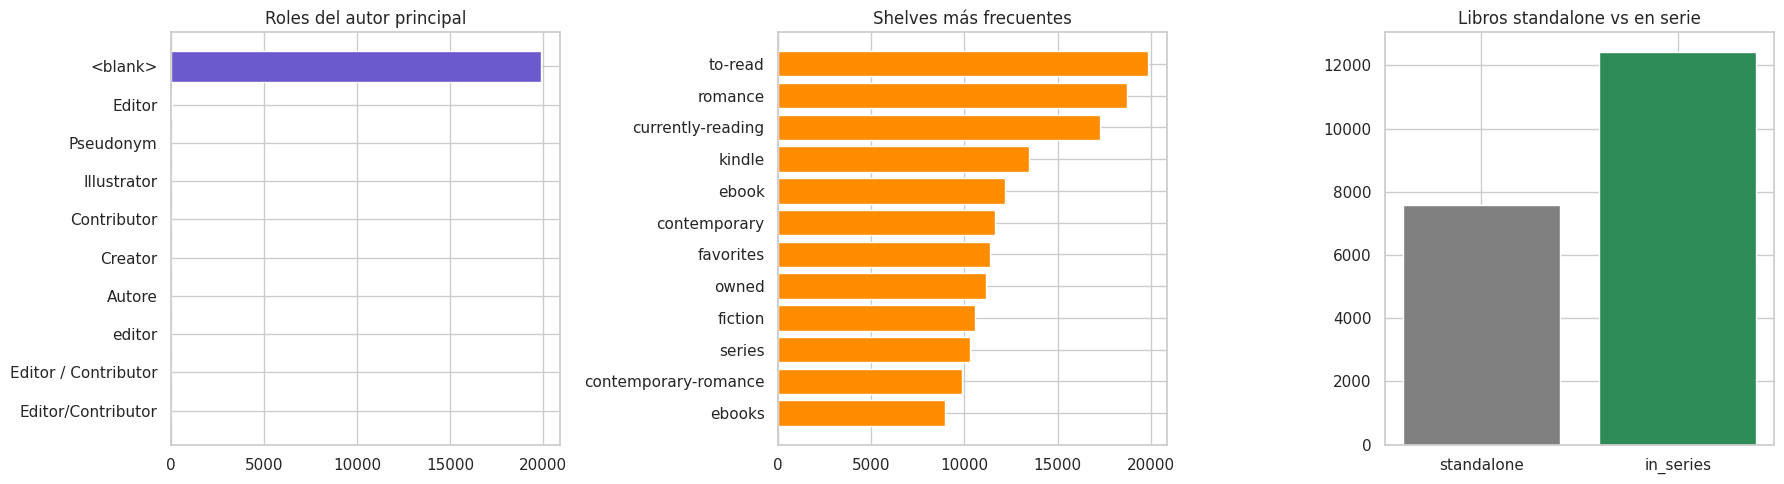

In [11]:
print('Top de variables categóricas observadas')
display(categoricals.head(20))
print(); print('Distribución de roles del autor principal')
display(author_artifacts['role_dist'].head(20))
print(); print('Top shelves observadas')
display(shelf_artifacts['top_shelf_names'].head(20))
print(); print('Standalone vs series')
display(series_artifacts['standalone_vs_series'])
print(); print('Distribución de cantidad de series asociadas por libro')
display(series_artifacts['series_length_dist'].head(15))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
top_roles = author_artifacts['role_dist'].head(10).iloc[::-1]
axes[0].barh(top_roles['role'], top_roles['books'], color='slateblue')
axes[0].set_title('Roles del autor principal')

top_shelves = shelf_artifacts['top_shelf_names'].head(12).iloc[::-1]
axes[1].barh(top_shelves['shelf_name'], top_shelves['book_count'], color='darkorange')
axes[1].set_title('Shelves más frecuentes')

series_view = series_artifacts['standalone_vs_series']
axes[2].bar(series_view['group'], series_view['books'], color=['grey', 'seagreen'])
axes[2].set_title('Libros standalone vs en serie')
plt.tight_layout()
plt.show()

## 7. Relaciones entre variables

Ahora sí pasamos de describir columnas a mirar relaciones. Interesan especialmente los vínculos entre demanda, popularidad, longitud, serialización y rating promedio, separando correlaciones plausibles de artefactos editoriales o de exposición.

,average_rating,ratings_count,text_reviews_count,to_read_count,interaction_count,explicit_rating_count,mean_user_rating,series_count,num_pages
average_rating,1.000,0.019,0.040,0.047,0.053,0.043,0.298,0.256,0.230
ratings_count,0.019,1.000,0.711,0.022,0.871,0.920,0.010,0.024,0.035
text_reviews_count,0.040,0.711,1.000,0.028,0.870,0.792,0.032,0.031,0.057
to_read_count,0.047,0.022,0.028,1.000,0.238,0.228,0.011,-0.048,0.048
interaction_count,0.053,0.871,0.870,0.238,1.000,0.953,0.031,0.017,0.075
explicit_rating_count,0.043,0.920,0.792,0.228,0.953,1.000,0.023,0.022,0.072
mean_user_rating,0.298,0.010,0.032,0.011,0.031,0.023,1.000,0.089,0.024
series_count,0.256,0.024,0.031,-0.048,0.017,0.022,0.089,1.000,0.031
num_pages,0.230,0.035,0.057,0.048,0.075,0.072,0.024,0.031,1.000


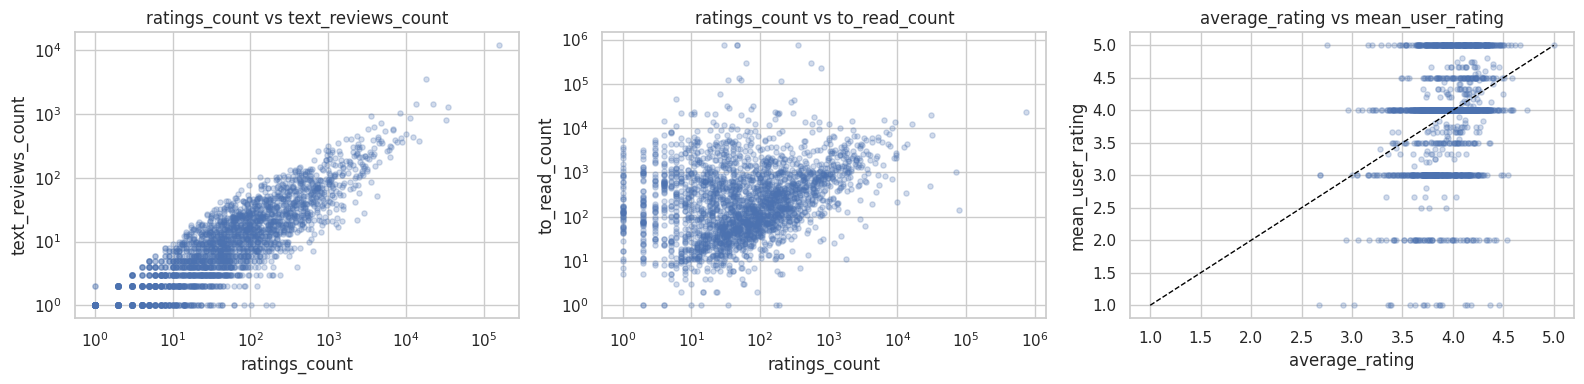

In [12]:
for col in ['ratings_count', 'text_reviews_count', 'to_read_count', 'interaction_count', 'explicit_rating_count', 'mean_user_rating', 'series_count', 'num_pages', 'average_rating']:
    if col in books_metrics.columns:
        books_metrics[col] = pd.to_numeric(books_metrics[col], errors='coerce')

corr_cols = [
    'average_rating', 'ratings_count', 'text_reviews_count', 'to_read_count',
    'interaction_count', 'explicit_rating_count', 'mean_user_rating',
    'series_count', 'num_pages'
]
corr_cols = [c for c in corr_cols if c in books_metrics.columns]
corr = books_metrics[corr_cols].corr(numeric_only=True)
display(corr.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plots = [
    ('ratings_count', 'text_reviews_count', 'ratings_count vs text_reviews_count'),
    ('ratings_count', 'to_read_count', 'ratings_count vs to_read_count'),
    ('average_rating', 'mean_user_rating', 'average_rating vs mean_user_rating'),
]
for ax, (x, y, title) in zip(axes, plots):
    if x in books_metrics.columns and y in books_metrics.columns:
        sample_base = books_metrics[[x, y]].dropna()
        sample = sample_base.sample(min(2500, len(sample_base)), random_state=42) if len(sample_base) else sample_base
        ax.scatter(sample[x], sample[y], alpha=0.25, s=14)
        ax.set_title(title)
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        if x in {'ratings_count', 'text_reviews_count', 'to_read_count'}:
            ax.set_xscale('log')
        if y in {'ratings_count', 'text_reviews_count', 'to_read_count'}:
            ax.set_yscale('log')
        if x == 'average_rating' and y == 'mean_user_rating' and len(sample):
            lo = max(1, min(sample[x].min(), sample[y].min()))
            hi = min(5, max(sample[x].max(), sample[y].max()))
            ax.plot([lo, hi], [lo, hi], linestyle='--', color='black', linewidth=1)
plt.tight_layout()
plt.show()

## 8. Naturaleza de las interacciones

Las interacciones también tienen su propia forma: lectura marcada, reseña vacía, rating explícito o rating ausente. Esto sirve para entender qué parte del comportamiento del usuario está realmente observada.

,mode,interactions,pct
0,shelf_only,48141,0.48141
1,rating_only,38653,0.38653
2,review,10389,0.10389
3,read_no_rating,2817,0.02817



Duración de lectura válida (0 a 365 días)


,stat,value
0,count,16913.000000
1,mean,7.929758
2,std,26.998040
3,min,0.000000
4,25%,0.000000
5,50%,1.000000
6,75%,4.000000
7,90%,13.000000
8,95%,31.400000
9,max,364.000000



Sesgo promedio de usuarios con >=3 ratings explícitos


,user_type,users,pct
0,generous,417,0.556742
1,balanced,266,0.355140
2,strict,66,0.088117



Crecimiento temporal de interacciones


,year,new_interactions
0,2006,1
1,2007,40
2,2008,1574
3,2009,899
4,2010,739
5,2011,651
6,2012,20034
7,2013,22574
8,2014,18944
9,2015,13622


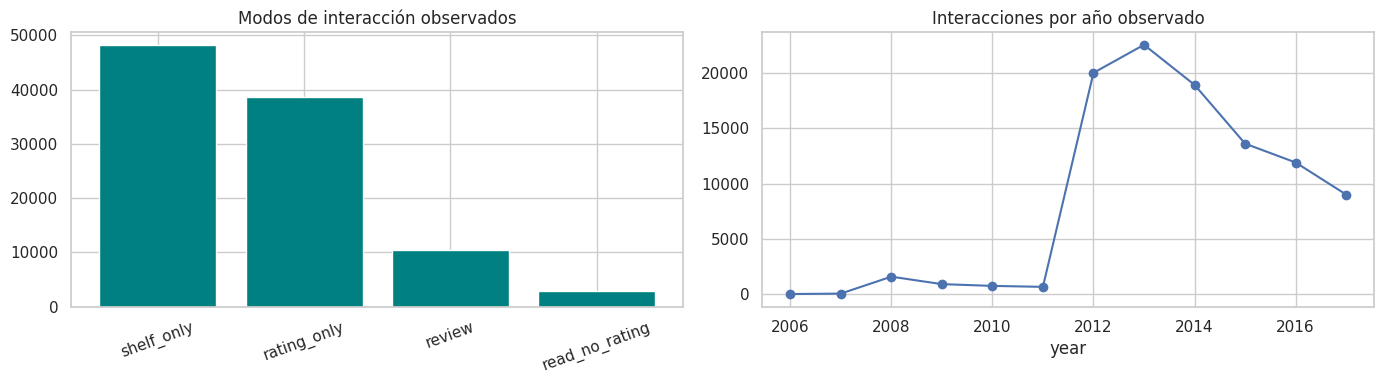

In [13]:
mode_rows = []
if len(interactions_num):
    has_review = interactions_raw['review_text_incomplete'].astype('string').str.strip().ne('') if 'review_text_incomplete' in interactions_raw.columns else pd.Series(False, index=interactions_num.index)
    has_rating = interactions_num['rating_clean'].notna()
    is_read = interactions_raw['is_read'].fillna(False).astype(bool) if 'is_read' in interactions_raw.columns else pd.Series(False, index=interactions_num.index)
    modes = pd.Series(np.select([has_review, has_rating, is_read], ['review', 'rating_only', 'read_no_rating'], 'shelf_only'))
    mode_dist = modes.value_counts().reset_index()
    mode_dist.columns = ['mode', 'interactions']
    mode_dist['pct'] = mode_dist['interactions'] / len(interactions_num)
else:
    mode_dist = pd.DataFrame(columns=['mode', 'interactions', 'pct'])
display(mode_dist)

duration = pd.Series(dtype='float64')
if {'started_at', 'read_at'}.issubset(interactions_num.columns):
    duration = (interactions_num['read_at'] - interactions_num['started_at']).dt.days
    duration = duration.where(duration.between(0, 365)).dropna()
duration_stats = duration.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).to_frame('value').reset_index().rename(columns={'index': 'stat'}) if not duration.empty else pd.DataFrame(columns=['stat', 'value'])
print(); print('Duración de lectura válida (0 a 365 días)')
display(duration_stats)

user_bias = pd.DataFrame(columns=['user_type', 'users', 'pct'])
if 'user_id' in interactions_num.columns:
    rated = interactions_num.dropna(subset=['rating_clean'])
    if len(rated):
        counts = rated.groupby('user_id')['rating_clean'].size()
        means = rated.groupby('user_id')['rating_clean'].mean()
        eligible = pd.DataFrame({'count': counts, 'mean': means})
        eligible = eligible[eligible['count'] >= 3]
        labels = np.select([eligible['mean'] < 3, eligible['mean'] < 3.67], ['strict', 'balanced'], 'generous') if len(eligible) else []
        user_bias = pd.Series(labels).value_counts().reset_index()
        user_bias.columns = ['user_type', 'users']
        user_bias['pct'] = user_bias['users'] / len(eligible) if len(eligible) else np.nan
print(); print('Sesgo promedio de usuarios con >=3 ratings explícitos')
display(user_bias)

growth = pd.DataFrame(columns=['year', 'new_interactions'])
if 'date_added' in interactions_num.columns:
    tmp = interactions_num.dropna(subset=['date_added']).copy()
    if len(tmp):
        tmp['year'] = tmp['date_added'].dt.year
        growth = tmp.groupby('year').size().reset_index(name='new_interactions').sort_values('year')
print(); print('Crecimiento temporal de interacciones')
display(growth.tail(12))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(mode_dist['mode'], mode_dist['interactions'], color='teal')
axes[0].set_title('Modos de interacción observados')
axes[0].tick_params(axis='x', rotation=20)
if len(growth):
    axes[1].plot(growth['year'], growth['new_interactions'], marker='o')
    axes[1].set_title('Interacciones por año observado')
    axes[1].set_xlabel('year')
plt.tight_layout()
plt.show()

## 9. Profundización específica — Romance

En Romance aparecieron dos señales claras en el perfil base: mucha serialización y una taxonomía muy dominante en `popular_shelves`. Por eso profundizamos en solapamiento semántico de subgéneros y en cómo cambian rating y engagement entre grupos temáticos.

In [14]:
ROMANCE_GROUPS = {
    'contemporary': ['contemporary-romance', 'contemporary', 'chick-lit', 'modern-romance'],
    'historical': ['historical-romance', 'regency', 'regency-romance', 'victorian'],
    'paranormal': ['paranormal-romance', 'paranormal', 'supernatural', 'vampire-romance'],
    'romantic_suspense': ['romantic-suspense', 'suspense-romance', 'thriller-romance'],
    'erotica': ['erotica', 'erotic-romance'],
    'new_adult': ['new-adult', 'college-romance', 'na'],
    'lgbtq': ['lgbtq', 'queer', 'm-m', 'mm-romance', 'f-f'],
    'general_romance': ['romance', 'sweet-romance', 'clean-romance', 'love-story'],
}

def assign_theme_flags(shelves_list, theme_map):
    names = set()
    if isinstance(shelves_list, list):
        for item in shelves_list:
            if isinstance(item, dict) and item.get('name'):
                names.add(str(item['name']).lower())
    return {theme: any(any(keyword in shelf for shelf in names) for keyword in keywords) for theme, keywords in theme_map.items()}

romance_flags_raw = pd.concat([
    books_raw[['book_id']].reset_index(drop=True),
    books_raw['popular_shelves'].apply(lambda s: assign_theme_flags(s, ROMANCE_GROUPS)).apply(pd.Series).reset_index(drop=True),
], axis=1)

romance_theme_books = books_metrics[['book_id', 'title', 'ratings_count', 'average_rating', 'series_count', 'to_read_count']].merge(romance_flags_raw, on='book_id', how='left')

theme_rows = []
for theme in ROMANCE_GROUPS:
    subset = romance_theme_books[romance_theme_books[theme].fillna(False)]
    if len(subset):
        theme_rows.append({
            'theme': theme,
            'books': len(subset),
            'pct_books': len(subset) / len(romance_theme_books),
            'median_ratings_count': subset['ratings_count'].median(),
            'median_average_rating': subset['average_rating'].median(),
            'pct_in_series': subset['series_count'].gt(0).mean(),
        })

theme_summary = pd.DataFrame(theme_rows).sort_values('books', ascending=False)
display(theme_summary)

display(pd.DataFrame([
    {'theme_a': left, 'theme_b': right, 'jaccard_books': len(set(romance_theme_books.loc[romance_theme_books[left].fillna(False), 'book_id']) & set(romance_theme_books.loc[romance_theme_books[right].fillna(False), 'book_id'])) / len(set(romance_theme_books.loc[romance_theme_books[left].fillna(False), 'book_id']) | set(romance_theme_books.loc[romance_theme_books[right].fillna(False), 'book_id']))}
    for left, right in combinations(ROMANCE_GROUPS.keys(), 2)
    if len(set(romance_theme_books.loc[romance_theme_books[left].fillna(False), 'book_id']) | set(romance_theme_books.loc[romance_theme_books[right].fillna(False), 'book_id'])) > 0
]).sort_values('jaccard_books', ascending=False).head(15))

,theme,books,pct_books,median_ratings_count,median_average_rating,pct_in_series
7,general_romance,19984,0.99920,53.0,3.91,0.621597
0,contemporary,15048,0.75240,62.0,3.91,0.636364
5,new_adult,13550,0.67750,71.5,3.92,0.668044
4,erotica,7225,0.36125,80.0,3.92,0.723737
2,paranormal,4322,0.21610,61.0,3.93,0.754512
6,lgbtq,3644,0.18220,66.0,3.81,0.606202
1,historical,3097,0.15485,40.0,3.86,0.608654
3,romantic_suspense,2685,0.13425,60.0,4.02,0.744879


,theme_a,theme_b,jaccard_books
6,contemporary,general_romance,0.752739
26,new_adult,general_romance,0.677707
4,contemporary,new_adult,0.593825
22,erotica,new_adult,0.377287
24,erotica,general_romance,0.361471
3,contemporary,erotica,0.357199
23,erotica,lgbtq,0.236941
15,paranormal,new_adult,0.232297
14,paranormal,erotica,0.219453
17,paranormal,general_romance,0.216151


In [15]:
romance_theme_inter = interactions_num[['book_id', 'rating_clean']].merge(romance_flags_raw, on='book_id', how='left')
rows = []
for theme in ROMANCE_GROUPS:
    subset = romance_theme_inter[romance_theme_inter[theme].fillna(False)]
    explicit = subset['rating_clean'].dropna()
    if len(subset):
        rows.append({
            'theme': theme,
            'interactions': len(subset),
            'explicit_ratings': explicit.size,
            'explicit_pct': explicit.size / len(subset),
            'mean_explicit_rating': explicit.mean() if explicit.size else np.nan,
            'pct_extreme_ratings': explicit.isin([1, 2, 4, 5]).mean() if explicit.size else np.nan,
        })

theme_ratings = pd.DataFrame(rows).sort_values('interactions', ascending=False)
display(theme_ratings)

popular_romance = romance_theme_books.sort_values('ratings_count', ascending=False).copy()
popular_romance['theme_principal'] = popular_romance[[c for c in ROMANCE_GROUPS.keys()]].fillna(False).idxmax(axis=1)
popular_romance.loc[~popular_romance[[c for c in ROMANCE_GROUPS.keys()]].fillna(False).any(axis=1), 'theme_principal'] = 'sin_grupo_claro'
print('Libros populares y su tema principal aproximado')
display(popular_romance[['title', 'theme_principal', 'ratings_count', 'average_rating', 'series_count', 'to_read_count']].head(20))

,theme,interactions,explicit_ratings,explicit_pct,mean_explicit_rating,pct_extreme_ratings
7,general_romance,6379,3095,0.485186,3.933764,0.789661
0,contemporary,5905,2899,0.490940,3.940324,0.789928
5,new_adult,5101,2354,0.461478,3.978760,0.798216
4,erotica,2712,1290,0.475664,3.982171,0.808527
2,paranormal,1312,649,0.494665,3.890601,0.756549
3,romantic_suspense,1012,518,0.511858,4.038610,0.820463
6,lgbtq,713,387,0.542777,4.002584,0.798450
1,historical,562,264,0.469751,3.742424,0.742424


Libros populares y su tema principal aproximado


,title,theme_principal,ratings_count,average_rating,series_count,to_read_count
7417,"Bridget Jones's Diary (Bridget Jones, #1)",contemporary,748926,3.75,1,22924.0
2658,"Shiver (The Wolves of Mercy Falls, #1)",contemporary,360934,3.78,1,21317.0
2007,Anna and the French Kiss (Anna and the French ...,contemporary,267364,4.07,1,52256.0
4448,"Slammed (Slammed, #1)",contemporary,154232,4.29,1,7222.0
2476,This Lullaby,contemporary,153555,4.03,0,50146.0
15081,"The Edge of Never (The Edge of Never, #1)",contemporary,119095,4.26,1,93234.0
4477,The Coincidence of Callie & Kayden (The Coinci...,contemporary,98438,4.20,1,8854.0
7140,"Maybe Someday (Maybe, #1)",contemporary,85268,4.32,1,3609.0
4513,"Bared to You (Crossfire, #1)",contemporary,84614,4.19,1,150865.0
16449,Mr. Maybe,contemporary,79538,3.41,0,145.0


## 10. Hallazgos y riesgos de interpretación

Cerramos con un resumen de lectura EDA: qué parece estructural del género, qué columnas son frágiles, dónde hay rarezas válidas y qué conviene tratar con cuidado en cualquier análisis posterior.

In [16]:
specific_takeaway = 'En Romance el catálogo se apoya mucho en series y en etiquetas que se solapan; eso vuelve a `popular_shelves` una fuente rica pero semánticamente ruidosa que conviene agrupar antes de interpretarla.'

zero_rating_pct = interactions_num['rating'].eq(0).mean() if 'rating' in interactions_num.columns else np.nan
review_blank_pct = interactions_missing_explicit.loc[
    interactions_missing_explicit['column'].eq('review_text_incomplete'),
    'missing_like_pct'
].iloc[0] if 'review_text_incomplete' in interactions_missing_explicit['column'].values else np.nan
work_dup_pct = books_raw['work_id'].duplicated().mean() if 'work_id' in books_raw.columns else np.nan
series_pct = series_artifacts['standalone_vs_series'].loc[
    series_artifacts['standalone_vs_series']['group'].eq('in_series'), 'pct'
].iloc[0]

hallazgos = pd.DataFrame([
    {'tema': 'Muestreo y forma', 'hallazgo': f"Se analizaron {len(books_raw):,} libros y {len(interactions_raw):,} interacciones del género."},
    {'tema': 'Metadatos faltantes', 'hallazgo': f"Los vacíos se concentran en campos editoriales y de identificación; `rating = 0` representa {zero_rating_pct:.1%} de las interacciones observadas."},
    {'tema': 'Texto de reseña', 'hallazgo': f"`review_text_incomplete` está vacío en {review_blank_pct:.1%} de la muestra; la huella textual existe, pero es minoritaria frente al evento de lectura o shelving."},
    {'tema': 'Ediciones y obras', 'hallazgo': f"`work_id` se repite en {work_dup_pct:.1%} de los registros de libros de la muestra, lo que sugiere convivencia de múltiples ediciones para una misma obra."},
    {'tema': 'Series', 'hallazgo': f"El {series_pct:.1%} de los libros cae dentro de alguna serie en esta muestra, así que la serialización forma parte de la naturaleza del catálogo."},
    {'tema': 'Outliers', 'hallazgo': 'Los atípicos aparecen sobre todo en métricas de popularidad (`ratings_count`, `text_reviews_count`) y suelen comportarse como cola larga natural, no como errores automáticos.'},
    {'tema': 'Relaciones', 'hallazgo': 'Las variables de demanda tienden a moverse juntas, mientras que la calidad percibida (`average_rating`) explica solo una parte del volumen de interacción.'},
    {'tema': 'Lectura EDA', 'hallazgo': specific_takeaway},
])

display(hallazgos)

,tema,hallazgo
0,Muestreo y forma,"Se analizaron 20,000 libros y 100,000 interacc..."
1,Metadatos faltantes,Los vacíos se concentran en campos editoriales...
2,Texto de reseña,`review_text_incomplete` está vacío en 89.6% d...
3,Ediciones y obras,`work_id` se repite en 7.4% de los registros d...
4,Series,El 62.1% de los libros cae dentro de alguna se...
5,Outliers,Los atípicos aparecen sobre todo en métricas d...
6,Relaciones,Las variables de demanda tienden a moverse jun...
7,Lectura EDA,En Romance el catálogo se apoya mucho en serie...
